In [1]:
%matplotlib inline

# scientific computing and plotting
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

# HDDM related packages
import pymc as pm
import hddm
import kabuki
import arviz as az
print("The current HDDM version is: ", hddm.__version__)
print("The current kabuki version is: ", kabuki.__version__)
print("The current PyMC version is: ", pm.__version__)
print("The current ArviZ version is: ", az.__version__)

The current HDDM version is:  1.0.1RC
The current kabuki version is:  0.6.5RC4
The current PyMC version is:  2.3.8
The current ArviZ version is:  0.15.1


In [2]:
# read data
data = pd.read_csv('MS_categ_id_hddm_stim.csv')
data

,subj_idx,val,id,stim,response,rt
0,7304,Good,Self,1,1,0.4236
1,7304,Bad,Other,0,0,0.5631
2,7304,Bad,Self,1,1,0.7198
3,7304,Good,Other,0,0,0.6799
4,7304,Good,Self,1,1,0.3560
...,...,...,...,...,...,...
14488,7345,Good,Other,0,0,0.3472
14489,7345,Bad,Self,1,1,0.4249
14490,7345,Bad,Self,1,1,0.3351
14491,7345,Bad,Other,0,0,0.4232


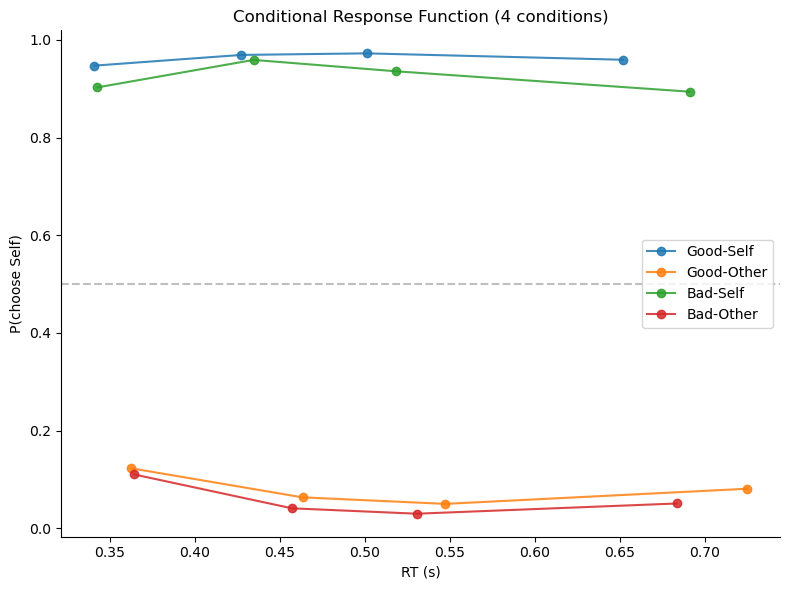

In [3]:
def conditional_response_plot(df, target=1):
    # 条件反应函数：四个条件（Good/Bad x Self/Other）选择 Self 的概率随 RT 变化
    quantiles = [0, 0.25, 0.5, 0.75, 1]
    df = df.copy()
    df['condition'] = df['val'] + '-' + df['id']

    cond_order = ['Good-Self', 'Good-Other', 'Bad-Self', 'Bad-Other']
    cond_colors = {'Good-Self': '#1f77b4', 'Good-Other': '#ff7f0e',
                     'Bad-Self': '#2ca02c', 'Bad-Other': '#d62728'}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cond in cond_order:
        c = df[df['condition'] == cond].copy()
        c['rt_bin'] = pd.qcut(c['rt'], quantiles, labels=False, duplicates='drop')
        g = c.groupby('rt_bin').agg(rt=('rt', 'mean'),
                                    prob=('response', lambda x: (x == target).mean())).reset_index()
        ax.plot(g['rt'], g['prob'], '-o', color=cond_colors[cond], label=cond, alpha=0.85)

    ax.axhline(0.5, ls='--', color='gray', alpha=0.5)
    ax.set(xlabel='RT (s)',
             ylabel='P(choose Self)' if target == 1 else 'P(choose Other)')
    ax.set_title('Conditional Response Function (4 conditions)')
    ax.legend()
    sns.despine()
    plt.tight_layout()
    return fig

fig = conditional_response_plot(data, target=1)
plt.show()

In [5]:
# accuracy coding
data['choice'] = data['response'].copy()                       # 保存 choice 编码（1=Self, 0=Other）
data['acc'] = (data['response'] == data['stim']).astype(int)   # 计算正确率

data['response'] = data['acc']   

In [6]:
#hddm_acc coding
hddm_id_m0_acc = hddm.HDDM(data, include=['a', 'v', 't','z'], depends_on={'z': 'id'})

hddm_id_m0_acc_idata = hddm_id_m0_acc.sample(5000, burn=1000, return_infdata=True, chains=4, dbname = 'hddm_id_m0_acc.db', db = 'pickle')
hddm_id_m0_acc.save('hddm_id_m0_acc.hddm')
# hddm.load('hddm_id_m0_acc.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[                  0%                  ] 8 of 5000 complete in 0.5 sec
[                  0%                  ] 15 of 5000 complete in 1.1 sec
[                  0%                  ] 22 of 5000 complete in 1.6 sec
[                  0%                  ] 29 of 5000 complete in 2.2 sec
[                  0%                  ] 36 of 5000 complete in 2.8 sec
[                  0%                  ] 43 of 5000 complete in 3.3 sec
[                  1%                  ] 50 of 5000 complete in 3.8 sec
[                  1%                  ] 57 of 5000 complete in 4.4 sec
[                  1%                  ] 64 of 5000 complete in 4.9 sec
[                  1%                  ] 71 of 5000 complete in 5.5 sec
[                  1%                  ] 78 of 5000 complete in 6.0 sec
[                  1%                  ] 85 of 5000 complete in 6.6 sec
[                  1%                  ] 92 of 5000 complete in 7.1 sec
[                  1%                  ] 99 of 5000 complete in 7

[                  0%                  ] 8 of 5000 complete in 0.6 sec
[                  0%                  ] 15 of 5000 complete in 1.1 sec
[                  0%                  ] 22 of 5000 complete in 1.7 sec
[                  0%                  ] 29 of 5000 complete in 2.2 sec
[                  0%                  ] 36 of 5000 complete in 2.8 sec
[                  0%                  ] 43 of 5000 complete in 3.3 sec
[                  1%                  ] 50 of 5000 complete in 3.9 sec
[                  1%                  ] 57 of 5000 complete in 4.4 sec
[                  1%                  ] 64 of 5000 complete in 5.0 sec
[                  1%                  ] 71 of 5000 complete in 5.5 sec
[                  1%                  ] 78 of 5000 complete in 6.1 sec
[                  1%                  ] 84 of 5000 complete in 6.6 sec
[                  1%                  ] 91 of 5000 complete in 7.2 sec
[                  1%                  ] 98 of 5000 complete in 7

[-----            15%                  ] 779 of 5000 complete in 61.2 sec
[-----            15%                  ] 786 of 5000 complete in 61.7 sec
[------           15%                  ] 793 of 5000 complete in 62.3 sec
[------           16%                  ] 800 of 5000 complete in 62.8 sec
[------           16%                  ] 807 of 5000 complete in 63.4 sec
[------           16%                  ] 814 of 5000 complete in 63.9 sec
[------           16%                  ] 821 of 5000 complete in 64.4 sec
[------           16%                  ] 828 of 5000 complete in 65.0 sec
[------           16%                  ] 835 of 5000 complete in 65.5 sec
[------           16%                  ] 842 of 5000 complete in 66.1 sec
[------           16%                  ] 849 of 5000 complete in 66.6 sec
[------           17%                  ] 856 of 5000 complete in 67.2 sec
[------           17%                  ] 863 of 5000 complete in 67.7 sec
[------           17%                 

...

[-----------------45%                  ] 2262 of 5000 complete in 179.0 sec
[-----------------45%                  ] 2269 of 5000 complete in 179.6 sec
[-----------------45%                  ] 2276 of 5000 complete in 180.1 sec
[-----------------45%                  ] 2283 of 5000 complete in 180.7 sec
[-----------------45%                  ] 2290 of 5000 complete in 181.2 sec
[-----------------45%                  ] 2297 of 5000 complete in 181.8 sec
[-----------------46%                  ] 2304 of 5000 complete in 182.3 sec
[-----------------46%                  ] 2311 of 5000 complete in 182.9 sec
[-----------------46%                  ] 2318 of 5000 complete in 183.4 sec
[-----------------46%                  ] 2325 of 5000 complete in 183.9 sec
[-----------------46%                  ] 2332 of 5000 complete in 184.5 sec
[-----------------46%                  ] 2339 of 5000 complete in 185.0 sec
[-----------------46%                  ] 2346 of 5000 complete in 185.5 sec
[-----------

[-----------------60%--                ] 3005 of 5000 complete in 236.6 sec
[-----------------60%--                ] 3012 of 5000 complete in 237.2 sec
[-----------------60%--                ] 3019 of 5000 complete in 237.7 sec
[-----------------60%--                ] 3026 of 5000 complete in 238.3 sec
[-----------------60%---               ] 3033 of 5000 complete in 238.8 sec
[-----------------60%---               ] 3040 of 5000 complete in 239.4 sec
[-----------------60%---               ] 3047 of 5000 complete in 239.9 sec
[-----------------61%---               ] 3054 of 5000 complete in 240.4 sec
[-----------------61%---               ] 3061 of 5000 complete in 241.0 sec
[-----------------61%---               ] 3068 of 5000 complete in 241.5 sec
[-----------------61%---               ] 3075 of 5000 complete in 242.1 sec
[-----------------61%---               ] 3082 of 5000 complete in 242.6 sec
[-----------------61%---               ] 3089 of 5000 complete in 243.1 sec
[-----------

[-----------------60%--                ] 3006 of 5000 complete in 237.9 sec
[-----------------60%--                ] 3013 of 5000 complete in 238.4 sec
[-----------------60%--                ] 3020 of 5000 complete in 239.0 sec
[-----------------60%---               ] 3027 of 5000 complete in 239.5 sec
[-----------------60%---               ] 3034 of 5000 complete in 240.1 sec
[-----------------60%---               ] 3041 of 5000 complete in 240.6 sec
[-----------------60%---               ] 3048 of 5000 complete in 241.1 sec
[-----------------61%---               ] 3055 of 5000 complete in 241.7 sec
[-----------------61%---               ] 3062 of 5000 complete in 242.2 sec
[-----------------61%---               ] 3069 of 5000 complete in 242.8 sec
[-----------------61%---               ] 3076 of 5000 complete in 243.3 sec
[-----------------61%---               ] 3083 of 5000 complete in 243.8 sec
[-----------------61%---               ] 3090 of 5000 complete in 244.4 sec
[-----------

[-----------------75%--------          ] 3750 of 5000 complete in 295.6 sec
[-----------------75%--------          ] 3757 of 5000 complete in 296.2 sec
[-----------------75%--------          ] 3764 of 5000 complete in 296.8 sec
[-----------------75%--------          ] 3771 of 5000 complete in 297.3 sec
[-----------------75%--------          ] 3778 of 5000 complete in 297.9 sec
[-----------------75%--------          ] 3785 of 5000 complete in 298.5 sec
[-----------------75%--------          ] 3792 of 5000 complete in 299.0 sec
[-----------------75%--------          ] 3799 of 5000 complete in 299.6 sec
[-----------------76%--------          ] 3805 of 5000 complete in 300.1 sec
[-----------------76%--------          ] 3812 of 5000 complete in 300.7 sec
[-----------------76%---------         ] 3818 of 5000 complete in 301.2 sec
[-----------------76%---------         ] 3825 of 5000 complete in 301.8 sec
[-----------------76%---------         ] 3832 of 5000 complete in 302.3 sec
[-----------

hddm sampling elpased time:  415.658 s
Start converting to InferenceData...


In [7]:
# model evaluate
az.summary(hddm_id_m0_acc_idata) 

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.550,0.054,1.453,1.653,0.001,0.001,1492.0,3871.0,1.00
a_std,0.310,0.047,0.227,0.398,0.002,0.002,426.0,1806.0,1.01
a_subj.7304,1.541,0.087,1.380,1.701,0.002,0.002,1262.0,2539.0,1.00
a_subj.7305,1.745,0.093,1.586,1.931,0.003,0.002,1408.0,2177.0,1.00
a_subj.7306,1.487,0.075,1.346,1.630,0.002,0.001,1805.0,2962.0,1.00
...,...,...,...,...,...,...,...,...,...
z_subj(Self).7342,0.312,0.022,0.274,0.355,0.000,0.000,6035.0,9685.0,1.00
z_subj(Self).7343,0.362,0.027,0.312,0.412,0.000,0.000,3768.0,7678.0,1.00
z_subj(Self).7344,0.373,0.026,0.325,0.420,0.000,0.000,5336.0,8201.0,1.00
z_subj(Self).7345,0.380,0.023,0.337,0.422,0.000,0.000,6620.0,9458.0,1.00


In [9]:
hddm_id_m0_acc_stats = hddm_id_m0_acc.gen_stats()
# hddm_id_acc_m0_stats
hddm_id_m0_acc_stats[hddm_id_m0_acc_stats.index.isin(['a', 'v',  'z_Intercept', 'z_C(id)[T.Self]'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.550236,0.053973,1.452477,1.513009,1.54762,1.584463,1.66292,0.00131
v,3.593713,0.142818,3.314753,3.498399,3.592704,3.688914,3.875615,0.002256


[-----------------89%-------------     ] 4472 of 5000 complete in 354.2 sec
[-----------------89%--------------    ] 4479 of 5000 complete in 354.7 sec
[-----------------89%--------------    ] 4486 of 5000 complete in 355.3 sec
[-----------------89%--------------    ] 4493 of 5000 complete in 355.8 sec
[-----------------90%--------------    ] 4500 of 5000 complete in 356.3 sec
[-----------------90%--------------    ] 4507 of 5000 complete in 356.9 sec
[-----------------90%--------------    ] 4514 of 5000 complete in 357.5 sec
[-----------------90%--------------    ] 4521 of 5000 complete in 358.0 sec
[-----------------90%--------------    ] 4528 of 5000 complete in 358.5 sec
[-----------------90%--------------    ] 4535 of 5000 complete in 359.1 sec
[-----------------90%--------------    ] 4542 of 5000 complete in 359.6 sec
[-----------------90%--------------    ] 4549 of 5000 complete in 360.2 sec
[-----------------91%--------------    ] 4556 of 5000 complete in 360.7 sec
[-----------

[-----------------89%-------------     ] 4471 of 5000 complete in 354.8 sec
[-----------------89%--------------    ] 4478 of 5000 complete in 355.3 sec
[-----------------89%--------------    ] 4485 of 5000 complete in 355.8 sec
[-----------------89%--------------    ] 4492 of 5000 complete in 356.4 sec
[-----------------89%--------------    ] 4499 of 5000 complete in 357.0 sec
[-----------------90%--------------    ] 4506 of 5000 complete in 357.5 sec
[-----------------90%--------------    ] 4513 of 5000 complete in 358.0 sec
[-----------------90%--------------    ] 4520 of 5000 complete in 358.6 sec
[-----------------90%--------------    ] 4527 of 5000 complete in 359.1 sec
[-----------------90%--------------    ] 4534 of 5000 complete in 359.7 sec
[-----------------90%--------------    ] 4541 of 5000 complete in 360.2 sec
[-----------------90%--------------    ] 4548 of 5000 complete in 360.8 sec
[-----------------91%--------------    ] 4555 of 5000 complete in 361.3 sec
[-----------

In [38]:
# HDDM choice coding 
# z change with different id
data['response'] = data['choice']#修改
hddm_id_m1_choice = hddm.HDDM(data, include=['a', 'v', 't', 'z'], bias=True)

hddm_id_m1_choice_idata = hddm_id_m1_choice.sample(5000, burn=1000, chains=4,
                                     return_infdata=True,
                                     dbname='hddm_id_m1_choice.db', db='pickle')
hddm_id_m1_choice.save('hddm_id_m1_choice.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[-----------------98%----------------- ] 4916 of 5000 complete in 2057.9 sec
[-----------------98%----------------- ] 4918 of 5000 complete in 2058.7 sec
[-----------------98%----------------- ] 4920 of 5000 complete in 2059.6 sec
[-----------------98%----------------- ] 4922 of 5000 complete in 2060.5 sec
[-----------------98%----------------- ] 4924 of 5000 complete in 2061.4 sec
[-----------------98%----------------- ] 4926 of 5000 complete in 2062.3 sec
[-----------------98%----------------- ] 4928 of 5000 complete in 2063.1 sec
[-----------------98%----------------- ] 4930 of 5000 complete in 2064.0 sec
[-----------------98%----------------- ] 4932 of 5000 complete in 2064.8 sec
[-----------------98%----------------- ] 4934 of 5000 complete in 2065.7 sec
[-----------------98%----------------- ] 4936 of 5000 complete in 2066.6 sec
[-----------------98%----------------- ] 4938 of 5000 complete in 2067.5 sec
[-----------------98%----------------- ] 4940 of 5000 complete in 2068.3 sec

[-----------------98%----------------- ] 4919 of 5000 complete in 2052.3 sec
[-----------------98%----------------- ] 4921 of 5000 complete in 2053.2 sec
[-----------------98%----------------- ] 4923 of 5000 complete in 2054.0 sec
[-----------------98%----------------- ] 4925 of 5000 complete in 2054.8 sec
[-----------------98%----------------- ] 4927 of 5000 complete in 2055.7 sec
[-----------------98%----------------- ] 4929 of 5000 complete in 2056.5 sec
[-----------------98%----------------- ] 4931 of 5000 complete in 2057.4 sec
[-----------------98%----------------- ] 4933 of 5000 complete in 2058.2 sec
[-----------------98%----------------- ] 4935 of 5000 complete in 2059.0 sec
[-----------------98%----------------- ] 4937 of 5000 complete in 2059.9 sec
[-----------------98%----------------- ] 4939 of 5000 complete in 2060.8 sec
[-----------------98%----------------- ] 4941 of 5000 complete in 2061.7 sec
[-----------------98%----------------- ] 4943 of 5000 complete in 2062.5 sec

[----             12%                  ] 640 of 5000 complete in 35.0 sec
[----             12%                  ] 649 of 5000 complete in 35.5 sec
[-----            13%                  ] 659 of 5000 complete in 36.0 sec
[-----            13%                  ] 669 of 5000 complete in 36.6 sec
[-----            13%                  ] 679 of 5000 complete in 37.1 sec
[-----            13%                  ] 689 of 5000 complete in 37.6 sec
[-----            13%                  ] 699 of 5000 complete in 38.2 sec
[-----            14%                  ] 708 of 5000 complete in 38.7 sec
[-----            14%                  ] 717 of 5000 complete in 39.2 sec
[-----            14%                  ] 727 of 5000 complete in 39.7 sec
[-----            14%                  ] 736 of 5000 complete in 40.2 sec
[-----            14%                  ] 745 of 5000 complete in 40.7 sec
[-----            15%                  ] 755 of 5000 complete in 41.3 sec
[-----            15%                 

[----             12%                  ] 646 of 5000 complete in 35.3 sec
[----             13%                  ] 656 of 5000 complete in 35.8 sec
[-----            13%                  ] 666 of 5000 complete in 36.3 sec
[-----            13%                  ] 676 of 5000 complete in 36.9 sec
[-----            13%                  ] 686 of 5000 complete in 37.4 sec
[-----            13%                  ] 696 of 5000 complete in 37.9 sec
[-----            14%                  ] 705 of 5000 complete in 38.5 sec
[-----            14%                  ] 714 of 5000 complete in 39.0 sec
[-----            14%                  ] 724 of 5000 complete in 39.5 sec
[-----            14%                  ] 733 of 5000 complete in 40.0 sec
[-----            14%                  ] 743 of 5000 complete in 40.6 sec
[-----            15%                  ] 753 of 5000 complete in 41.1 sec
[-----            15%                  ] 763 of 5000 complete in 41.6 sec
[-----            15%                 

[------------     33%                  ] 1698 of 5000 complete in 92.8 sec
[------------     34%                  ] 1708 of 5000 complete in 93.3 sec
[-------------    34%                  ] 1718 of 5000 complete in 93.8 sec
[-------------    34%                  ] 1728 of 5000 complete in 94.4 sec
[-------------    34%                  ] 1738 of 5000 complete in 94.9 sec
[-------------    34%                  ] 1748 of 5000 complete in 95.4 sec
[-------------    35%                  ] 1757 of 5000 complete in 95.9 sec
[-------------    35%                  ] 1767 of 5000 complete in 96.5 sec
[-------------    35%                  ] 1777 of 5000 complete in 97.0 sec
[-------------    35%                  ] 1787 of 5000 complete in 97.6 sec
[-------------    35%                  ] 1797 of 5000 complete in 98.1 sec
[-------------    36%                  ] 1807 of 5000 complete in 98.7 sec
[-------------    36%                  ] 1817 of 5000 complete in 99.2 sec
[-------------    36%    

[-----------------55%-                 ] 2783 of 5000 complete in 148.9 sec
[-----------------55%-                 ] 2793 of 5000 complete in 149.4 sec
[-----------------56%-                 ] 2803 of 5000 complete in 150.0 sec
[-----------------56%-                 ] 2813 of 5000 complete in 150.5 sec
[-----------------56%-                 ] 2823 of 5000 complete in 151.0 sec
[-----------------56%-                 ] 2833 of 5000 complete in 151.5 sec
[-----------------56%-                 ] 2843 of 5000 complete in 152.0 sec
[-----------------57%-                 ] 2853 of 5000 complete in 152.6 sec
[-----------------57%-                 ] 2863 of 5000 complete in 153.1 sec
[-----------------57%-                 ] 2873 of 5000 complete in 153.6 sec
[-----------------57%-                 ] 2883 of 5000 complete in 154.2 sec
[-----------------57%-                 ] 2893 of 5000 complete in 154.7 sec
[-----------------58%--                ] 2903 of 5000 complete in 155.2 sec
[-----------

[-----------------77%---------         ] 3853 of 5000 complete in 205.5 sec
[-----------------77%---------         ] 3863 of 5000 complete in 206.0 sec
[-----------------77%---------         ] 3873 of 5000 complete in 206.5 sec
[-----------------77%---------         ] 3883 of 5000 complete in 207.0 sec
[-----------------77%---------         ] 3893 of 5000 complete in 207.6 sec
[-----------------78%---------         ] 3903 of 5000 complete in 208.1 sec
[-----------------78%---------         ] 3913 of 5000 complete in 208.6 sec
[-----------------78%---------         ] 3923 of 5000 complete in 209.1 sec
[-----------------78%---------         ] 3933 of 5000 complete in 209.7 sec
[-----------------78%---------         ] 3943 of 5000 complete in 210.2 sec
[-----------------79%----------        ] 3953 of 5000 complete in 210.7 sec
[-----------------79%----------        ] 3963 of 5000 complete in 211.3 sec
[-----------------79%----------        ] 3973 of 5000 complete in 211.8 sec
[-----------

[-----------------76%---------         ] 3841 of 5000 complete in 207.0 sec
[-----------------77%---------         ] 3851 of 5000 complete in 207.6 sec
[-----------------77%---------         ] 3861 of 5000 complete in 208.1 sec
[-----------------77%---------         ] 3871 of 5000 complete in 208.7 sec
[-----------------77%---------         ] 3881 of 5000 complete in 209.2 sec
[-----------------77%---------         ] 3891 of 5000 complete in 209.7 sec
[-----------------78%---------         ] 3901 of 5000 complete in 210.3 sec
[-----------------78%---------         ] 3911 of 5000 complete in 210.8 sec
[-----------------78%---------         ] 3921 of 5000 complete in 211.3 sec
[-----------------78%---------         ] 3931 of 5000 complete in 211.8 sec
[-----------------78%---------         ] 3941 of 5000 complete in 212.4 sec
[-----------------79%----------        ] 3951 of 5000 complete in 212.9 sec
[-----------------79%----------        ] 3961 of 5000 complete in 213.4 sec
[-----------

In [39]:
az.summary(hddm_id_m1_choice_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.518,0.047,1.429,1.605,0.001,0.001,1962.0,5458.0,1.0
a_std,0.269,0.040,0.195,0.341,0.001,0.001,1020.0,3022.0,1.0
a_subj.7304,1.548,0.078,1.406,1.699,0.002,0.001,1388.0,2660.0,1.0
a_subj.7305,1.718,0.084,1.563,1.876,0.002,0.001,1972.0,3491.0,1.0
a_subj.7306,1.495,0.075,1.354,1.633,0.002,0.001,1784.0,2813.0,1.0
...,...,...,...,...,...,...,...,...,...
z_subj.7342,0.298,0.018,0.265,0.332,0.000,0.000,4226.0,6598.0,1.0
z_subj.7343,0.297,0.018,0.262,0.331,0.000,0.000,3948.0,6686.0,1.0
z_subj.7344,0.321,0.018,0.289,0.355,0.000,0.000,5608.0,8778.0,1.0
z_subj.7345,0.333,0.018,0.300,0.369,0.000,0.000,4182.0,7944.0,1.0


In [40]:
hddm_id_m1_choice_stats = hddm_id_m1_choice.gen_stats()
hddm_id_m1_choice_stats[hddm_id_m1_choice_stats.index.isin(['a', 'v', 't', 'z'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.518315,0.046724,1.43067,1.486915,1.516877,1.548258,1.616142,0.001025
v,3.535047,0.133093,3.275654,3.446006,3.535155,3.62227,3.801716,0.001838
t,0.236122,0.005954,0.2246,0.232099,0.236035,0.240081,0.248239,0.000105
z,0.339722,0.007058,0.32557,0.334975,0.339668,0.34444,0.35335,0.000253


[-----------------98%----------------- ] 4918 of 5000 complete in 262.3 sec
[-----------------98%----------------- ] 4928 of 5000 complete in 262.8 sec
[-----------------98%----------------- ] 4938 of 5000 complete in 263.3 sec
[-----------------98%----------------- ] 4947 of 5000 complete in 263.8 sec
[-----------------99%----------------- ] 4957 of 5000 complete in 264.4 sec
[-----------------99%----------------- ] 4967 of 5000 complete in 264.9 sec
[-----------------99%----------------- ] 4977 of 5000 complete in 265.4 sec
[-----------------99%----------------- ] 4986 of 5000 complete in 266.0 sec
[-----------------99%----------------- ] 4996 of 5000 complete in 266.5 sec
[-----------------100%-----------------] 5000 of 5000 complete in 266.8 sec
hddm sampling elpased time:  266.915 s
[-----------------98%----------------- ] 4904 of 5000 complete in 263.9 sec
[-----------------98%----------------- ] 4914 of 5000 complete in 264.5 sec
[-----------------98%----------------- ] 4924 of 

In [27]:
#HDDMStimCoding
#hddmstim_z_flip
# ========== z flip：测起始点偏差（accuracy coding） ==========
data['response'] = data['acc']

hddmStim_zflip_m1 = hddm.HDDMStimCoding(
    data,
    stim_col='stim',
    split_param='z',
    bias=True,
    include=['v', 'a', 't'],      # 没有 'z'，z 由 split_param 处理
  )

hddmStim_zflip_m1_idata = hddmStim_zflip_m1.sample(5000, burn=1000, return_infdata=True,
                                               chains=4, dbname='hddmStim_zflip_m1.db', db='pickle')
hddmStim_zflip_m1.save('hddmStim_zflip_m1.hddm')

Setting model to be non-informative
Adding z to includes.
No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[                  0%                  ] 6 of 5000 complete in 0.5 sec
[                  0%                  ] 11 of 5000 complete in 1.1 sec
[                  0%                  ] 16 of 5000 complete in 1.6 sec
[                  0%                  ] 21 of 5000 complete in 2.1 sec
[                  0%                  ] 26 of 5000 complete in 2.7 sec
[                  0%                  ] 31 of 5000 complete in 3.2 sec
[                  0%                  ] 36 of 5000 complete in 3.8 sec
[                  0%                  ] 41 of 5000 complete in 4.4 sec
[                  0%                  ] 46 of 5000 complete in 4.9 sec
[                  1%                  ] 51 of 5000 complete in 5.5 sec
[                  1%                  ] 56 of 5000 complete in 6.0 sec
[                  1%                  ] 61 of 5000 complete in 6.6 sec
[                  1%                  ] 66 of 5000 complete in 7.1 sec
[                  1%                  ] 71 of 5000 complete in 7

[                  0%                  ] 6 of 5000 complete in 0.6 sec
[                  0%                  ] 11 of 5000 complete in 1.1 sec
[                  0%                  ] 16 of 5000 complete in 1.7 sec
[                  0%                  ] 21 of 5000 complete in 2.3 sec
[                  0%                  ] 26 of 5000 complete in 2.8 sec
[                  0%                  ] 31 of 5000 complete in 3.4 sec
[                  0%                  ] 36 of 5000 complete in 4.0 sec
[                  0%                  ] 41 of 5000 complete in 4.5 sec
[                  0%                  ] 46 of 5000 complete in 5.1 sec
[                  1%                  ] 51 of 5000 complete in 5.6 sec
[                  1%                  ] 56 of 5000 complete in 6.2 sec
[                  1%                  ] 61 of 5000 complete in 6.8 sec
[                  1%                  ] 66 of 5000 complete in 7.3 sec
[                  1%                  ] 71 of 5000 complete in 7

[----             11%                  ] 560 of 5000 complete in 62.9 sec
[----             11%                  ] 565 of 5000 complete in 63.4 sec
[----             11%                  ] 570 of 5000 complete in 64.0 sec
[----             11%                  ] 575 of 5000 complete in 64.5 sec
[----             11%                  ] 580 of 5000 complete in 65.0 sec
[----             11%                  ] 585 of 5000 complete in 65.6 sec
[----             11%                  ] 590 of 5000 complete in 66.1 sec
[----             11%                  ] 595 of 5000 complete in 66.6 sec
[----             12%                  ] 600 of 5000 complete in 67.2 sec
[----             12%                  ] 605 of 5000 complete in 67.7 sec
[----             12%                  ] 610 of 5000 complete in 68.3 sec
[----             12%                  ] 615 of 5000 complete in 68.8 sec
[----             12%                  ] 620 of 5000 complete in 69.3 sec
[----             12%                 

...

[-----------------62%---               ] 3122 of 5000 complete in 367.3 sec
[-----------------62%---               ] 3127 of 5000 complete in 367.9 sec
[-----------------62%---               ] 3132 of 5000 complete in 368.5 sec
[-----------------62%---               ] 3137 of 5000 complete in 369.0 sec
[-----------------62%---               ] 3142 of 5000 complete in 369.6 sec
[-----------------62%---               ] 3147 of 5000 complete in 370.2 sec
[-----------------63%---               ] 3152 of 5000 complete in 370.7 sec
[-----------------63%---               ] 3157 of 5000 complete in 371.3 sec
[-----------------63%----              ] 3162 of 5000 complete in 371.8 sec
[-----------------63%----              ] 3167 of 5000 complete in 372.4 sec
[-----------------63%----              ] 3172 of 5000 complete in 372.9 sec
[-----------------63%----              ] 3177 of 5000 complete in 373.5 sec
[-----------------63%----              ] 3182 of 5000 complete in 374.0 sec
[-----------

[-----------------75%--------          ] 3767 of 5000 complete in 421.3 sec
[-----------------75%--------          ] 3772 of 5000 complete in 421.8 sec
[-----------------75%--------          ] 3777 of 5000 complete in 422.4 sec
[-----------------75%--------          ] 3782 of 5000 complete in 422.9 sec
[-----------------75%--------          ] 3787 of 5000 complete in 423.5 sec
[-----------------75%--------          ] 3792 of 5000 complete in 424.1 sec
[-----------------75%--------          ] 3797 of 5000 complete in 424.6 sec
[-----------------76%--------          ] 3802 of 5000 complete in 425.1 sec
[-----------------76%--------          ] 3807 of 5000 complete in 425.7 sec
[-----------------76%--------          ] 3812 of 5000 complete in 426.2 sec
[-----------------76%---------         ] 3817 of 5000 complete in 426.8 sec
[-----------------76%---------         ] 3822 of 5000 complete in 427.3 sec
[-----------------76%---------         ] 3827 of 5000 complete in 427.9 sec
[-----------

[-----------------73%-------           ] 3656 of 5000 complete in 429.0 sec
[-----------------73%-------           ] 3661 of 5000 complete in 429.6 sec
[-----------------73%-------           ] 3666 of 5000 complete in 430.2 sec
[-----------------73%-------           ] 3671 of 5000 complete in 430.8 sec
[-----------------73%-------           ] 3676 of 5000 complete in 431.3 sec
[-----------------73%-------           ] 3681 of 5000 complete in 431.9 sec
[-----------------73%--------          ] 3686 of 5000 complete in 432.5 sec
[-----------------73%--------          ] 3691 of 5000 complete in 433.1 sec
[-----------------73%--------          ] 3696 of 5000 complete in 433.7 sec
[-----------------74%--------          ] 3701 of 5000 complete in 434.2 sec
[-----------------74%--------          ] 3706 of 5000 complete in 434.8 sec
[-----------------74%--------          ] 3711 of 5000 complete in 435.4 sec
[-----------------74%--------          ] 3716 of 5000 complete in 435.9 sec
[-----------

[-----------------86%------------      ] 4302 of 5000 complete in 481.8 sec
[-----------------86%------------      ] 4307 of 5000 complete in 482.4 sec
[-----------------86%------------      ] 4312 of 5000 complete in 483.0 sec
[-----------------86%------------      ] 4317 of 5000 complete in 483.6 sec
[-----------------86%------------      ] 4322 of 5000 complete in 484.2 sec
[-----------------86%------------      ] 4327 of 5000 complete in 484.7 sec
[-----------------86%------------      ] 4332 of 5000 complete in 485.3 sec
[-----------------86%------------      ] 4337 of 5000 complete in 485.9 sec
[-----------------86%------------      ] 4342 of 5000 complete in 486.4 sec
[-----------------86%-------------     ] 4347 of 5000 complete in 487.0 sec
[-----------------87%-------------     ] 4352 of 5000 complete in 487.5 sec
[-----------------87%-------------     ] 4357 of 5000 complete in 488.0 sec
[-----------------87%-------------     ] 4362 of 5000 complete in 488.6 sec
[-----------

[-----------------83%-----------       ] 4188 of 5000 complete in 490.1 sec
[-----------------83%-----------       ] 4193 of 5000 complete in 490.7 sec
[-----------------83%-----------       ] 4198 of 5000 complete in 491.2 sec
[-----------------84%-----------       ] 4203 of 5000 complete in 491.8 sec
[-----------------84%-----------       ] 4208 of 5000 complete in 492.4 sec
[-----------------84%------------      ] 4213 of 5000 complete in 492.9 sec
[-----------------84%------------      ] 4218 of 5000 complete in 493.5 sec
[-----------------84%------------      ] 4223 of 5000 complete in 494.0 sec
[-----------------84%------------      ] 4228 of 5000 complete in 494.6 sec
[-----------------84%------------      ] 4233 of 5000 complete in 495.1 sec
[-----------------84%------------      ] 4238 of 5000 complete in 495.7 sec
[-----------------84%------------      ] 4243 of 5000 complete in 496.3 sec
[-----------------84%------------      ] 4248 of 5000 complete in 496.8 sec
[-----------

In [28]:
#hddmstim_v_flip
# ========== v flip：测 drift rate（choice coding） ==========
data['response'] = data['choice']

hddmStim_vflip_m1 = hddm.HDDMStimCoding(
    data,
    stim_col='stim',
    split_param='v',
    drift_criterion=False,
    bias=True,
    include=['v', 'a', 't', 'z'],
  )

hddmStim_vflip_m1_idata = hddmStim_vflip_m1.sample(5000, burn=1000, return_infdata=True,
                                               chains=4, dbname='hddmStim_vflip_m1.db', db='pickle')
hddmStim_vflip_m1.save('hddmStim_vflip_m1.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[-----------------94%---------------   ] 4722 of 5000 complete in 550.4 sec
[-----------------94%---------------   ] 4727 of 5000 complete in 550.9 sec
[-----------------94%---------------   ] 4732 of 5000 complete in 551.4 sec
[-----------------94%----------------  ] 4737 of 5000 complete in 552.0 sec
[-----------------94%----------------  ] 4742 of 5000 complete in 552.5 sec
[-----------------94%----------------  ] 4747 of 5000 complete in 553.0 sec
[-----------------95%----------------  ] 4752 of 5000 complete in 553.6 sec
[-----------------95%----------------  ] 4757 of 5000 complete in 554.1 sec
[-----------------95%----------------  ] 4762 of 5000 complete in 554.7 sec
[-----------------95%----------------  ] 4767 of 5000 complete in 555.2 sec
[-----------------95%----------------  ] 4772 of 5000 complete in 555.7 sec
[-----------------95%----------------  ] 4777 of 5000 complete in 556.3 sec
[-----------------95%----------------  ] 4782 of 5000 complete in 556.8 sec
[-----------

[-----------------96%----------------  ] 4834 of 5000 complete in 541.9 sec
[-----------------96%----------------  ] 4839 of 5000 complete in 542.4 sec
[-----------------96%----------------  ] 4844 of 5000 complete in 543.0 sec
[-----------------96%----------------  ] 4849 of 5000 complete in 543.6 sec
[-----------------97%----------------  ] 4854 of 5000 complete in 544.1 sec
[-----------------97%----------------  ] 4859 of 5000 complete in 544.7 sec
[-----------------97%----------------  ] 4864 of 5000 complete in 545.2 sec
[-----------------97%----------------- ] 4869 of 5000 complete in 545.8 sec
[-----------------97%----------------- ] 4874 of 5000 complete in 546.3 sec
[-----------------97%----------------- ] 4879 of 5000 complete in 546.9 sec
[-----------------97%----------------- ] 4884 of 5000 complete in 547.4 sec
[-----------------97%----------------- ] 4889 of 5000 complete in 547.9 sec
[-----------------97%----------------- ] 4894 of 5000 complete in 548.5 sec
[-----------

[--                6%                  ] 349 of 5000 complete in 28.9 sec
[--                7%                  ] 356 of 5000 complete in 29.5 sec
[--                7%                  ] 362 of 5000 complete in 30.0 sec
[--                7%                  ] 368 of 5000 complete in 30.5 sec
[--                7%                  ] 374 of 5000 complete in 31.1 sec
[--                7%                  ] 380 of 5000 complete in 31.6 sec
[--                7%                  ] 386 of 5000 complete in 32.1 sec
[--                7%                  ] 392 of 5000 complete in 32.6 sec
[---               7%                  ] 398 of 5000 complete in 33.1 sec
[---               8%                  ] 404 of 5000 complete in 33.6 sec
[---               8%                  ] 410 of 5000 complete in 34.1 sec
[---               8%                  ] 416 of 5000 complete in 34.6 sec
[---               8%                  ] 423 of 5000 complete in 35.2 sec
[---               8%                 

...

[-----------------62%---               ] 3128 of 5000 complete in 273.1 sec
[-----------------62%---               ] 3134 of 5000 complete in 273.6 sec
[-----------------62%---               ] 3140 of 5000 complete in 274.2 sec
[-----------------62%---               ] 3146 of 5000 complete in 274.7 sec
[-----------------63%---               ] 3152 of 5000 complete in 275.2 sec
[-----------------63%----              ] 3158 of 5000 complete in 275.8 sec
[-----------------63%----              ] 3164 of 5000 complete in 276.3 sec
[-----------------63%----              ] 3170 of 5000 complete in 276.8 sec
[-----------------63%----              ] 3176 of 5000 complete in 277.3 sec
[-----------------63%----              ] 3183 of 5000 complete in 277.9 sec
[-----------------63%----              ] 3189 of 5000 complete in 278.4 sec
[-----------------63%----              ] 3195 of 5000 complete in 278.9 sec
[-----------------64%----              ] 3202 of 5000 complete in 279.5 sec
[-----------

[-----------------64%----              ] 3217 of 5000 complete in 276.6 sec
[-----------------64%----              ] 3223 of 5000 complete in 277.1 sec
[-----------------64%----              ] 3229 of 5000 complete in 277.7 sec
[-----------------64%----              ] 3235 of 5000 complete in 278.2 sec
[-----------------64%----              ] 3241 of 5000 complete in 278.8 sec
[-----------------64%----              ] 3247 of 5000 complete in 279.3 sec
[-----------------65%----              ] 3253 of 5000 complete in 279.9 sec
[-----------------65%----              ] 3259 of 5000 complete in 280.4 sec
[-----------------65%----              ] 3265 of 5000 complete in 280.9 sec
[-----------------65%----              ] 3271 of 5000 complete in 281.5 sec
[-----------------65%----              ] 3277 of 5000 complete in 282.0 sec
[-----------------65%----              ] 3283 of 5000 complete in 282.5 sec
[-----------------65%----              ] 3289 of 5000 complete in 283.0 sec
[-----------

[-----------------75%--------          ] 3785 of 5000 complete in 331.4 sec
[-----------------75%--------          ] 3791 of 5000 complete in 332.0 sec
[-----------------75%--------          ] 3797 of 5000 complete in 332.5 sec
[-----------------76%--------          ] 3803 of 5000 complete in 333.1 sec
[-----------------76%--------          ] 3809 of 5000 complete in 333.6 sec
[-----------------76%--------          ] 3815 of 5000 complete in 334.2 sec
[-----------------76%---------         ] 3821 of 5000 complete in 334.8 sec
[-----------------76%---------         ] 3827 of 5000 complete in 335.3 sec
[-----------------76%---------         ] 3833 of 5000 complete in 335.9 sec
[-----------------76%---------         ] 3839 of 5000 complete in 336.4 sec
[-----------------76%---------         ] 3845 of 5000 complete in 336.9 sec
[-----------------77%---------         ] 3851 of 5000 complete in 337.5 sec
[-----------------77%---------         ] 3857 of 5000 complete in 338.1 sec
[-----------

[-----------------78%---------         ] 3915 of 5000 complete in 335.1 sec
[-----------------78%---------         ] 3922 of 5000 complete in 335.6 sec
[-----------------78%---------         ] 3929 of 5000 complete in 336.2 sec
[-----------------78%---------         ] 3936 of 5000 complete in 336.7 sec
[-----------------78%---------         ] 3943 of 5000 complete in 337.3 sec
[-----------------79%----------        ] 3950 of 5000 complete in 337.8 sec
[-----------------79%----------        ] 3957 of 5000 complete in 338.4 sec
[-----------------79%----------        ] 3964 of 5000 complete in 339.0 sec
[-----------------79%----------        ] 3970 of 5000 complete in 339.5 sec
[-----------------79%----------        ] 3976 of 5000 complete in 340.0 sec
[-----------------79%----------        ] 3983 of 5000 complete in 340.6 sec
[-----------------79%----------        ] 3990 of 5000 complete in 341.2 sec
[-----------------79%----------        ] 3997 of 5000 complete in 341.7 sec
[-----------

hddm sampling elpased time:  463.213 s
Start converting to InferenceData...


In [30]:
summary = az.summary(hddmStim_zflip_m1_idata)
group_params = summary[~summary.index.str.contains('_subj.')]
print(group_params)# 看 z 是否 > 0.5 → 偏向 Self

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail   
a      1.084  0.021   1.046    1.125      0.000    0.000   10348.0   10609.0  \
a_std  0.123  0.016   0.093    0.153      0.000    0.000    6681.0    9427.0   
v      0.020  0.018  -0.014    0.056      0.002    0.001     111.0     262.0   
v_std  0.019  0.014   0.000    0.044      0.001    0.001     102.0      98.0   
t      0.305  0.008   0.291    0.319      0.000    0.000   15163.0   11189.0   
t_std  0.048  0.006   0.038    0.058      0.000    0.000   12721.0   10422.0   
z      0.670  0.007   0.657    0.683      0.000    0.000    8935.0   12786.0   
z_std  0.177  0.025   0.134    0.226      0.000    0.000    4628.0    8742.0   

       r_hat  
a       1.00  
a_std   1.00  
v       1.05  
v_std   1.05  
t       1.00  
t_std   1.00  
z       1.00  
z_std   1.00  


In [31]:
summary = az.summary(hddmStim_vflip_m1_idata)
group_params = summary[~summary.index.str.contains('_subj.')]
print(group_params)   # 看 v

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail   
a      1.083  0.021   1.043    1.120      0.000    0.000    9261.0   10064.0  \
a_std  0.123  0.016   0.093    0.153      0.000    0.000    6443.0    9028.0   
v      0.018  0.022  -0.020    0.061      0.004    0.003      30.0      59.0   
v_std  0.019  0.014   0.000    0.045      0.001    0.001      62.0      61.0   
t      0.306  0.007   0.292    0.320      0.000    0.000   14415.0   11506.0   
t_std  0.048  0.006   0.038    0.059      0.000    0.000   10785.0   10091.0   
z      0.669  0.006   0.658    0.680      0.000    0.000    7018.0   11361.0   
z_std  0.148  0.018   0.116    0.182      0.000    0.000    4881.0    8196.0   

       r_hat  
a       1.00  
a_std   1.00  
v       1.10  
v_std   1.07  
t       1.00  
t_std   1.00  
z       1.00  
z_std   1.00  
[-----------------93%---------------   ] 4657 of 5000 complete in 390.6 sec
[-----------------93%---------------   ] 4663 of 5000 complete in 39

[-----------------88%-------------     ] 4447 of 5000 complete in 389.0 sec
[-----------------89%-------------     ] 4453 of 5000 complete in 389.5 sec
[-----------------89%-------------     ] 4459 of 5000 complete in 390.1 sec
[-----------------89%-------------     ] 4466 of 5000 complete in 390.6 sec
[-----------------89%-------------     ] 4472 of 5000 complete in 391.2 sec
[-----------------89%--------------    ] 4478 of 5000 complete in 391.7 sec
[-----------------89%--------------    ] 4484 of 5000 complete in 392.2 sec
[-----------------89%--------------    ] 4491 of 5000 complete in 392.8 sec
[-----------------89%--------------    ] 4498 of 5000 complete in 393.3 sec
[-----------------90%--------------    ] 4505 of 5000 complete in 393.9 sec
[-----------------90%--------------    ] 4511 of 5000 complete in 394.4 sec
[-----------------90%--------------    ] 4517 of 5000 complete in 395.0 sec
[-----------------90%--------------    ] 4523 of 5000 complete in 395.5 sec
[-----------

In [12]:
#HDDMRegression
#accuracy coding
#choice coding
#stim coding: accuracy coding + v flip
#stim coding: choice coding + z flp
#accuracy coding
data['response'] = data['acc']

z_reg = [{"model": "z ~ 1", "link_func": lambda x: x}]#如果是 "z ~ 1+（c）"，rhat就会变成2

hddmReg_id_m0_acc = hddm.HDDMRegressor(
    data,
    z_reg,
    bias=True, p_outlier=0.05,
    include=['v', 'a', 't', 'z'],
    depends_on={'z':['id']},
    group_only_regressors=False
)

hddmReg_id_m0_acc_idata = hddmReg_id_m0_acc.sample(5000, burn=1000, chains=4, return_infdata=True, dbname = 'hddmReg_id_m0_acc.db', db = 'pickle')
hddmReg_id_m0_acc.save('hddmReg_id_m0_acc.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[-----------------98%----------------- ] 4926 of 5000 complete in 1769.1 sec
[-----------------98%----------------- ] 4928 of 5000 complete in 1769.8 sec
[-----------------98%----------------- ] 4930 of 5000 complete in 1770.5 sec
[-----------------98%----------------- ] 4932 of 5000 complete in 1771.2 sec
[-----------------98%----------------- ] 4934 of 5000 complete in 1772.0 sec
[-----------------98%----------------- ] 4936 of 5000 complete in 1772.7 sec
[-----------------98%----------------- ] 4938 of 5000 complete in 1773.4 sec
[-----------------98%----------------- ] 4940 of 5000 complete in 1774.1 sec
[-----------------98%----------------- ] 4942 of 5000 complete in 1774.7 sec
[-----------------98%----------------- ] 4944 of 5000 complete in 1775.5 sec
[-----------------98%----------------- ] 4946 of 5000 complete in 1776.2 sec
[-----------------98%----------------- ] 4948 of 5000 complete in 1776.9 sec
[-----------------99%----------------- ] 4950 of 5000 complete in 1777.6 sec

[-----------------98%----------------- ] 4926 of 5000 complete in 1774.6 sec
[-----------------98%----------------- ] 4928 of 5000 complete in 1775.3 sec
[-----------------98%----------------- ] 4930 of 5000 complete in 1776.0 sec
[-----------------98%----------------- ] 4932 of 5000 complete in 1776.7 sec
[-----------------98%----------------- ] 4934 of 5000 complete in 1777.4 sec
[-----------------98%----------------- ] 4936 of 5000 complete in 1778.1 sec
[-----------------98%----------------- ] 4938 of 5000 complete in 1778.8 sec
[-----------------98%----------------- ] 4940 of 5000 complete in 1779.5 sec
[-----------------98%----------------- ] 4942 of 5000 complete in 1780.2 sec
[-----------------98%----------------- ] 4944 of 5000 complete in 1780.9 sec
[-----------------98%----------------- ] 4946 of 5000 complete in 1781.6 sec
[-----------------98%----------------- ] 4948 of 5000 complete in 1782.3 sec
[-----------------99%----------------- ] 4950 of 5000 complete in 1783.0 sec

[-                 2%                  ] 144 of 5000 complete in 37.4 sec
[-                 2%                  ] 146 of 5000 complete in 38.0 sec
[-                 2%                  ] 148 of 5000 complete in 38.5 sec
[-                 3%                  ] 150 of 5000 complete in 39.0 sec
[-                 3%                  ] 152 of 5000 complete in 39.5 sec
[-                 3%                  ] 154 of 5000 complete in 40.0 sec
[-                 3%                  ] 156 of 5000 complete in 40.6 sec
[-                 3%                  ] 158 of 5000 complete in 41.1 sec
[-                 3%                  ] 160 of 5000 complete in 41.6 sec
[-                 3%                  ] 162 of 5000 complete in 42.1 sec
[-                 3%                  ] 164 of 5000 complete in 42.7 sec
[-                 3%                  ] 167 of 5000 complete in 43.4 sec
[-                 3%                  ] 169 of 5000 complete in 43.9 sec
[-                 3%                 

...

[-----------------90%--------------    ] 4500 of 5000 complete in 1172.4 sec
[-----------------90%--------------    ] 4502 of 5000 complete in 1173.0 sec
[-----------------90%--------------    ] 4504 of 5000 complete in 1173.5 sec
[-----------------90%--------------    ] 4506 of 5000 complete in 1174.1 sec
[-----------------90%--------------    ] 4508 of 5000 complete in 1174.6 sec
[-----------------90%--------------    ] 4510 of 5000 complete in 1175.2 sec
[-----------------90%--------------    ] 4512 of 5000 complete in 1175.7 sec
[-----------------90%--------------    ] 4514 of 5000 complete in 1176.2 sec
[-----------------90%--------------    ] 4516 of 5000 complete in 1176.8 sec
[-----------------90%--------------    ] 4518 of 5000 complete in 1177.3 sec
[-----------------90%--------------    ] 4520 of 5000 complete in 1177.8 sec
[-----------------90%--------------    ] 4522 of 5000 complete in 1178.4 sec
[-----------------90%--------------    ] 4524 of 5000 complete in 1178.9 sec

[-----------------91%--------------    ] 4563 of 5000 complete in 1182.9 sec
[-----------------91%--------------    ] 4565 of 5000 complete in 1183.4 sec
[-----------------91%--------------    ] 4567 of 5000 complete in 1184.0 sec
[-----------------91%--------------    ] 4569 of 5000 complete in 1184.6 sec
[-----------------91%--------------    ] 4571 of 5000 complete in 1185.1 sec
[-----------------91%--------------    ] 4573 of 5000 complete in 1185.7 sec
[-----------------91%--------------    ] 4575 of 5000 complete in 1186.2 sec
[-----------------91%--------------    ] 4577 of 5000 complete in 1186.7 sec
[-----------------91%--------------    ] 4579 of 5000 complete in 1187.3 sec
[-----------------91%--------------    ] 4581 of 5000 complete in 1187.8 sec
[-----------------91%--------------    ] 4583 of 5000 complete in 1188.4 sec
[-----------------91%--------------    ] 4585 of 5000 complete in 1188.9 sec
[-----------------91%--------------    ] 4587 of 5000 complete in 1189.4 sec

[-----------------94%---------------   ] 4713 of 5000 complete in 1229.7 sec
[-----------------94%---------------   ] 4715 of 5000 complete in 1230.2 sec
[-----------------94%---------------   ] 4717 of 5000 complete in 1230.7 sec
[-----------------94%---------------   ] 4719 of 5000 complete in 1231.3 sec
[-----------------94%---------------   ] 4721 of 5000 complete in 1231.8 sec
[-----------------94%---------------   ] 4723 of 5000 complete in 1232.3 sec
[-----------------94%---------------   ] 4725 of 5000 complete in 1232.8 sec
[-----------------94%---------------   ] 4727 of 5000 complete in 1233.3 sec
[-----------------94%---------------   ] 4729 of 5000 complete in 1233.9 sec
[-----------------94%---------------   ] 4731 of 5000 complete in 1234.4 sec
[-----------------94%---------------   ] 4733 of 5000 complete in 1234.9 sec
[-----------------94%---------------   ] 4735 of 5000 complete in 1235.5 sec
[-----------------94%----------------  ] 4737 of 5000 complete in 1236.0 sec

[-----------------95%----------------  ] 4777 of 5000 complete in 1239.8 sec
[-----------------95%----------------  ] 4779 of 5000 complete in 1240.4 sec
[-----------------95%----------------  ] 4781 of 5000 complete in 1240.9 sec
[-----------------95%----------------  ] 4783 of 5000 complete in 1241.4 sec
[-----------------95%----------------  ] 4785 of 5000 complete in 1241.9 sec
[-----------------95%----------------  ] 4787 of 5000 complete in 1242.4 sec
[-----------------95%----------------  ] 4790 of 5000 complete in 1243.2 sec
[-----------------95%----------------  ] 4792 of 5000 complete in 1243.7 sec
[-----------------95%----------------  ] 4794 of 5000 complete in 1244.2 sec
[-----------------95%----------------  ] 4796 of 5000 complete in 1244.8 sec
[-----------------95%----------------  ] 4798 of 5000 complete in 1245.3 sec
[-----------------96%----------------  ] 4800 of 5000 complete in 1245.8 sec
[-----------------96%----------------  ] 4802 of 5000 complete in 1246.3 sec

hddm sampling elpased time:  1327.332 s
Start converting to InferenceData...


In [13]:
az.summary(hddmReg_id_m0_acc_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.552,0.055,1.455,1.660,0.001,0.001,1517.0,5138.0,1.00
a_std,0.313,0.048,0.229,0.401,0.002,0.002,452.0,2016.0,1.01
a_subj.7304,1.540,0.085,1.381,1.696,0.002,0.002,1222.0,2159.0,1.00
a_subj.7305,1.748,0.091,1.585,1.920,0.002,0.002,1679.0,3033.0,1.00
a_subj.7306,1.488,0.076,1.350,1.632,0.002,0.001,1783.0,2603.0,1.00
...,...,...,...,...,...,...,...,...,...
z_Intercept_subj(Self).7342,0.312,0.022,0.270,0.352,0.000,0.000,5774.0,8933.0,1.00
z_Intercept_subj(Self).7343,0.363,0.027,0.313,0.415,0.000,0.000,3690.0,8187.0,1.00
z_Intercept_subj(Self).7344,0.373,0.026,0.327,0.423,0.000,0.000,4909.0,7873.0,1.00
z_Intercept_subj(Self).7345,0.381,0.023,0.337,0.424,0.000,0.000,6485.0,8880.0,1.00


[-----------------99%----------------- ] 4993 of 5000 complete in 1296.8 sec
[-----------------99%----------------- ] 4995 of 5000 complete in 1297.3 sec
[-----------------99%----------------- ] 4997 of 5000 complete in 1297.9 sec
[-----------------99%----------------- ] 4999 of 5000 complete in 1298.4 sec
[-----------------100%-----------------] 5001 of 5000 complete in 1298.9 sec
hddm sampling elpased time:  1299.15 s
[-----------------99%----------------- ] 4988 of 5000 complete in 1296.9 sec
[-----------------99%----------------- ] 4990 of 5000 complete in 1297.4 sec
[-----------------99%----------------- ] 4992 of 5000 complete in 1298.0 sec
[-----------------99%----------------- ] 4994 of 5000 complete in 1298.5 sec
[-----------------99%----------------- ] 4996 of 5000 complete in 1299.1 sec
[-----------------99%----------------- ] 4998 of 5000 complete in 1299.6 sec
[-----------------100%-----------------] 5000 of 5000 complete in 1300.1 sec
[-----------------100%---------------

In [15]:
hddmReg_id_m0_acc_stats = hddmReg_id_m0_acc.gen_stats()
hddmReg_id_m0_acc_stats[hddmReg_id_m0_acc_stats.index.isin(['a', 'z', 'v','z_Intercept', 'z_C(id)[T.Self]'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.552445,0.054506,1.453318,1.515413,1.550208,1.586359,1.670157,0.001297
v,3.593262,0.141784,3.314766,3.499341,3.592559,3.686401,3.876576,0.002187


In [18]:
#choice coding
data['response'] = data['choice']

z_reg = [{"model": "z ~ 1", "link_func": lambda x: x}]

hddmReg_id_m2_choice = hddm.HDDMRegressor(
    data,
    z_reg,
    bias=True, p_outlier=0.05,
    include=['v', 'a', 't', 'z'],
    depends_on={'z':['id']},
    group_only_regressors=False
)

hddmReg_id_m2_choice_idata = hddmReg_id_m2_choice.sample(5000, burn=1000, chains=4, return_infdata=True, dbname = 'hddmReg_id_m2_choice.db', db = 'pickle')
hddmReg_id_m2_choice.save('hddmReg_id_m2_choice.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[                  0%                  ] 3 of 5000 complete in 0.5 sec
[                  0%                  ] 5 of 5000 complete in 1.0 sec
[                  0%                  ] 7 of 5000 complete in 1.5 sec
[                  0%                  ] 9 of 5000 complete in 2.1 sec
[                  0%                  ] 11 of 5000 complete in 2.6 sec
[                  0%                  ] 13 of 5000 complete in 3.1 sec
[                  0%                  ] 15 of 5000 complete in 3.7 sec
[                  0%                  ] 17 of 5000 complete in 4.2 sec
[                  0%                  ] 19 of 5000 complete in 4.7 sec
[                  0%                  ] 21 of 5000 complete in 5.3 sec
[                  0%                  ] 23 of 5000 complete in 5.9 sec
[                  0%                  ] 25 of 5000 complete in 6.4 sec
[                  0%                  ] 27 of 5000 complete in 7.0 sec
[                  0%                  ] 29 of 5000 complete in 7.5 

[                  0%                  ] 4 of 5000 complete in 0.8 sec
[                  0%                  ] 6 of 5000 complete in 1.3 sec
[                  0%                  ] 8 of 5000 complete in 1.8 sec
[                  0%                  ] 10 of 5000 complete in 2.3 sec
[                  0%                  ] 12 of 5000 complete in 2.8 sec
[                  0%                  ] 14 of 5000 complete in 3.4 sec
[                  0%                  ] 16 of 5000 complete in 3.9 sec
[                  0%                  ] 18 of 5000 complete in 4.5 sec
[                  0%                  ] 20 of 5000 complete in 5.1 sec
[                  0%                  ] 22 of 5000 complete in 5.7 sec
[                  0%                  ] 24 of 5000 complete in 6.2 sec
[                  0%                  ] 26 of 5000 complete in 6.7 sec
[                  0%                  ] 28 of 5000 complete in 7.2 sec
[                  0%                  ] 30 of 5000 complete in 7.9

[-                 4%                  ] 229 of 5000 complete in 60.4 sec
[-                 4%                  ] 231 of 5000 complete in 61.0 sec
[-                 4%                  ] 233 of 5000 complete in 61.5 sec
[-                 4%                  ] 235 of 5000 complete in 62.0 sec
[-                 4%                  ] 237 of 5000 complete in 62.6 sec
[-                 4%                  ] 239 of 5000 complete in 63.1 sec
[-                 4%                  ] 241 of 5000 complete in 63.6 sec
[-                 4%                  ] 243 of 5000 complete in 64.1 sec
[-                 4%                  ] 245 of 5000 complete in 64.6 sec
[-                 4%                  ] 247 of 5000 complete in 65.1 sec
[-                 4%                  ] 249 of 5000 complete in 65.7 sec
[-                 5%                  ] 251 of 5000 complete in 66.2 sec
[-                 5%                  ] 253 of 5000 complete in 66.7 sec
[-                 5%                 

...

[-----------------91%--------------    ] 4553 of 5000 complete in 1211.9 sec
[-----------------91%--------------    ] 4555 of 5000 complete in 1212.5 sec
[-----------------91%--------------    ] 4557 of 5000 complete in 1213.0 sec
[-----------------91%--------------    ] 4559 of 5000 complete in 1213.5 sec
[-----------------91%--------------    ] 4561 of 5000 complete in 1214.0 sec
[-----------------91%--------------    ] 4563 of 5000 complete in 1214.5 sec
[-----------------91%--------------    ] 4565 of 5000 complete in 1215.0 sec
[-----------------91%--------------    ] 4567 of 5000 complete in 1215.5 sec
[-----------------91%--------------    ] 4569 of 5000 complete in 1216.1 sec
[-----------------91%--------------    ] 4571 of 5000 complete in 1216.6 sec
[-----------------91%--------------    ] 4573 of 5000 complete in 1217.1 sec
[-----------------91%--------------    ] 4575 of 5000 complete in 1217.6 sec
[-----------------91%--------------    ] 4577 of 5000 complete in 1218.1 sec

[-----------------90%--------------    ] 4527 of 5000 complete in 1232.0 sec
[-----------------90%--------------    ] 4529 of 5000 complete in 1232.5 sec
[-----------------90%--------------    ] 4531 of 5000 complete in 1233.1 sec
[-----------------90%--------------    ] 4533 of 5000 complete in 1233.6 sec
[-----------------90%--------------    ] 4535 of 5000 complete in 1234.1 sec
[-----------------90%--------------    ] 4537 of 5000 complete in 1234.6 sec
[-----------------90%--------------    ] 4539 of 5000 complete in 1235.2 sec
[-----------------90%--------------    ] 4541 of 5000 complete in 1235.7 sec
[-----------------90%--------------    ] 4543 of 5000 complete in 1236.2 sec
[-----------------90%--------------    ] 4545 of 5000 complete in 1236.7 sec
[-----------------90%--------------    ] 4547 of 5000 complete in 1237.2 sec
[-----------------90%--------------    ] 4549 of 5000 complete in 1237.7 sec
[-----------------91%--------------    ] 4551 of 5000 complete in 1238.2 sec

[-----------------95%----------------  ] 4765 of 5000 complete in 1268.4 sec
[-----------------95%----------------  ] 4767 of 5000 complete in 1269.0 sec
[-----------------95%----------------  ] 4769 of 5000 complete in 1269.5 sec
[-----------------95%----------------  ] 4771 of 5000 complete in 1270.1 sec
[-----------------95%----------------  ] 4773 of 5000 complete in 1270.6 sec
[-----------------95%----------------  ] 4775 of 5000 complete in 1271.2 sec
[-----------------95%----------------  ] 4777 of 5000 complete in 1271.8 sec
[-----------------95%----------------  ] 4779 of 5000 complete in 1272.3 sec
[-----------------95%----------------  ] 4781 of 5000 complete in 1272.9 sec
[-----------------95%----------------  ] 4783 of 5000 complete in 1273.5 sec
[-----------------95%----------------  ] 4785 of 5000 complete in 1274.1 sec
[-----------------95%----------------  ] 4787 of 5000 complete in 1274.7 sec
[-----------------95%----------------  ] 4789 of 5000 complete in 1275.3 sec

[-----------------94%----------------  ] 4739 of 5000 complete in 1288.3 sec
[-----------------94%----------------  ] 4741 of 5000 complete in 1288.9 sec
[-----------------94%----------------  ] 4743 of 5000 complete in 1289.4 sec
[-----------------94%----------------  ] 4745 of 5000 complete in 1290.0 sec
[-----------------94%----------------  ] 4747 of 5000 complete in 1290.5 sec
[-----------------94%----------------  ] 4749 of 5000 complete in 1291.1 sec
[-----------------95%----------------  ] 4751 of 5000 complete in 1291.6 sec
[-----------------95%----------------  ] 4753 of 5000 complete in 1292.2 sec
[-----------------95%----------------  ] 4755 of 5000 complete in 1292.7 sec
[-----------------95%----------------  ] 4757 of 5000 complete in 1293.3 sec
[-----------------95%----------------  ] 4759 of 5000 complete in 1293.9 sec
[-----------------95%----------------  ] 4761 of 5000 complete in 1294.4 sec
[-----------------95%----------------  ] 4763 of 5000 complete in 1295.0 sec

[-----------------94%---------------   ] 4730 of 5000 complete in 1334.8 sec
[-----------------94%---------------   ] 4732 of 5000 complete in 1335.3 sec
[-----------------94%---------------   ] 4734 of 5000 complete in 1335.9 sec
[-----------------94%---------------   ] 4736 of 5000 complete in 1336.4 sec
[-----------------94%----------------  ] 4738 of 5000 complete in 1337.0 sec
[-----------------94%----------------  ] 4740 of 5000 complete in 1337.5 sec
[-----------------94%----------------  ] 4742 of 5000 complete in 1338.1 sec
[-----------------94%----------------  ] 4744 of 5000 complete in 1338.6 sec
[-----------------94%----------------  ] 4746 of 5000 complete in 1339.2 sec
[-----------------94%----------------  ] 4748 of 5000 complete in 1339.7 sec
[-----------------95%----------------  ] 4750 of 5000 complete in 1340.3 sec
[-----------------95%----------------  ] 4752 of 5000 complete in 1340.8 sec
[-----------------95%----------------  ] 4754 of 5000 complete in 1341.3 sec

In [19]:
az.summary(hddmReg_id_m2_choice_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.086,0.021,1.048,1.125,0.000,0.0,10179.0,11207.0,1.00
a_std,0.123,0.016,0.094,0.155,0.000,0.0,6104.0,8957.0,1.00
a_subj.7304,1.041,0.039,0.968,1.117,0.001,0.0,3739.0,4131.0,1.00
a_subj.7305,1.345,0.050,1.252,1.441,0.001,0.0,5668.0,8900.0,1.00
a_subj.7306,1.126,0.039,1.058,1.203,0.000,0.0,7113.0,7748.0,1.00
...,...,...,...,...,...,...,...,...,...
z_Intercept_subj(Self).7342,0.655,0.023,0.614,0.698,0.001,0.0,1300.0,3384.0,1.01
z_Intercept_subj(Self).7343,0.706,0.017,0.674,0.740,0.000,0.0,6975.0,9297.0,1.00
z_Intercept_subj(Self).7344,0.660,0.020,0.623,0.698,0.000,0.0,7762.0,9775.0,1.00
z_Intercept_subj(Self).7345,0.702,0.017,0.671,0.736,0.000,0.0,9748.0,9980.0,1.00


In [22]:
hddmReg_id_m2_choice_stats = hddmReg_id_m2_choice.gen_stats()
hddmReg_id_m2_choice_stats[hddmReg_id_m2_choice_stats.index.isin(['a', 'v', 't', 'z_Intercept', 'z_C(id)[T.Self]'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.08596,0.020834,1.046461,1.071973,1.085428,1.099591,1.127698,0.000192
v,-0.196045,0.024931,-0.244182,-0.213094,-0.196983,-0.179765,-0.144835,0.000982
t,0.307349,0.007507,0.292995,0.3024,0.307213,0.312296,0.32247,0.000066


In [35]:
#hddmreg_stim_v_flip
#type1 reg
data['response'] = data['choice']
data['stim2'] = data['stim'].map({1: 1, 0: -1}) 

v_reg = [{'model': "v ~ 1 + stim2", 'link_func': lambda x: x}] 

hddmReg_stim_vflip_m2 = hddm.HDDMRegressor(
    data,
    v_reg,
    bias=True, p_outlier=0.05,
    include=['v', 'a', 't', 'z'],
    depends_on={'z':['id']},
    group_only_regressors=False
)

hddmReg_stim_vflip_m2_idata = hddmReg_stim_vflip_m2.sample(5000, burn=1000, chains=4, return_infdata=True, dbname = 'hddmReg_stim_vflip_m2.db', db = 'pickle')
hddmReg_stim_vflip_m2.save('hddmReg_stim_vflip_m2.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[                  0%                  ] 2 of 5000 complete in 0.6 sec
[                  0%                  ] 3 of 5000 complete in 1.1 sec
[                  0%                  ] 5 of 5000 complete in 2.0 sec
[                  0%                  ] 7 of 5000 complete in 3.0 sec
[                  0%                  ] 9 of 5000 complete in 3.9 sec
[                  0%                  ] 11 of 5000 complete in 4.8 sec
[                  0%                  ] 13 of 5000 complete in 5.7 sec
[                  0%                  ] 15 of 5000 complete in 6.6 sec
[                  0%                  ] 16 of 5000 complete in 7.1 sec
[                  0%                  ] 17 of 5000 complete in 7.6 sec
[                  0%                  ] 19 of 5000 complete in 8.6 sec
[                  0%                  ] 21 of 5000 complete in 9.5 sec
[                  0%                  ] 23 of 5000 complete in 10.3 sec
[                  0%                  ] 25 of 5000 complete in 11.2

[                  0%                  ] 2 of 5000 complete in 0.6 sec
[                  0%                  ] 3 of 5000 complete in 1.1 sec
[                  0%                  ] 5 of 5000 complete in 2.0 sec
[                  0%                  ] 7 of 5000 complete in 2.9 sec
[                  0%                  ] 9 of 5000 complete in 3.8 sec
[                  0%                  ] 11 of 5000 complete in 4.7 sec
[                  0%                  ] 13 of 5000 complete in 5.5 sec
[                  0%                  ] 15 of 5000 complete in 6.4 sec
[                  0%                  ] 17 of 5000 complete in 7.4 sec
[                  0%                  ] 19 of 5000 complete in 8.3 sec
[                  0%                  ] 21 of 5000 complete in 9.2 sec
[                  0%                  ] 23 of 5000 complete in 10.1 sec
[                  0%                  ] 25 of 5000 complete in 11.0 sec
[                  0%                  ] 27 of 5000 complete in 11.

[-                 4%                  ] 221 of 5000 complete in 92.1 sec
[-                 4%                  ] 223 of 5000 complete in 92.9 sec
[-                 4%                  ] 225 of 5000 complete in 93.7 sec
[-                 4%                  ] 227 of 5000 complete in 94.5 sec
[-                 4%                  ] 229 of 5000 complete in 95.3 sec
[-                 4%                  ] 231 of 5000 complete in 96.1 sec
[-                 4%                  ] 233 of 5000 complete in 97.0 sec
[-                 4%                  ] 235 of 5000 complete in 97.8 sec
[-                 4%                  ] 237 of 5000 complete in 98.7 sec
[-                 4%                  ] 239 of 5000 complete in 99.5 sec
[-                 4%                  ] 241 of 5000 complete in 100.4 sec
[-                 4%                  ] 243 of 5000 complete in 101.2 sec
[-                 4%                  ] 245 of 5000 complete in 102.0 sec
[-                 4%              

...

[-----------------89%--------------    ] 4494 of 5000 complete in 1856.0 sec
[-----------------89%--------------    ] 4496 of 5000 complete in 1856.9 sec
[-----------------89%--------------    ] 4498 of 5000 complete in 1857.8 sec
[-----------------90%--------------    ] 4500 of 5000 complete in 1858.7 sec
[-----------------90%--------------    ] 4502 of 5000 complete in 1859.5 sec
[-----------------90%--------------    ] 4504 of 5000 complete in 1860.4 sec
[-----------------90%--------------    ] 4506 of 5000 complete in 1861.2 sec
[-----------------90%--------------    ] 4508 of 5000 complete in 1862.1 sec
[-----------------90%--------------    ] 4510 of 5000 complete in 1862.9 sec
[-----------------90%--------------    ] 4512 of 5000 complete in 1863.8 sec
[-----------------90%--------------    ] 4514 of 5000 complete in 1864.6 sec
[-----------------90%--------------    ] 4516 of 5000 complete in 1865.4 sec
[-----------------90%--------------    ] 4518 of 5000 complete in 1866.3 sec

[-----------------89%--------------    ] 4492 of 5000 complete in 1879.3 sec
[-----------------89%--------------    ] 4494 of 5000 complete in 1880.1 sec
[-----------------89%--------------    ] 4496 of 5000 complete in 1881.0 sec
[-----------------89%--------------    ] 4498 of 5000 complete in 1881.8 sec
[-----------------90%--------------    ] 4500 of 5000 complete in 1882.7 sec
[-----------------90%--------------    ] 4502 of 5000 complete in 1883.5 sec
[-----------------90%--------------    ] 4504 of 5000 complete in 1884.3 sec
[-----------------90%--------------    ] 4506 of 5000 complete in 1885.2 sec
[-----------------90%--------------    ] 4508 of 5000 complete in 1886.0 sec
[-----------------90%--------------    ] 4510 of 5000 complete in 1886.8 sec
[-----------------90%--------------    ] 4512 of 5000 complete in 1887.7 sec
[-----------------90%--------------    ] 4514 of 5000 complete in 1888.5 sec
[-----------------90%--------------    ] 4516 of 5000 complete in 1889.3 sec

[-----------------94%---------------   ] 4706 of 5000 complete in 1943.9 sec
[-----------------94%---------------   ] 4708 of 5000 complete in 1944.6 sec
[-----------------94%---------------   ] 4710 of 5000 complete in 1945.4 sec
[-----------------94%---------------   ] 4712 of 5000 complete in 1946.2 sec
[-----------------94%---------------   ] 4714 of 5000 complete in 1946.9 sec
[-----------------94%---------------   ] 4716 of 5000 complete in 1947.6 sec
[-----------------94%---------------   ] 4718 of 5000 complete in 1948.4 sec
[-----------------94%---------------   ] 4720 of 5000 complete in 1949.2 sec
[-----------------94%---------------   ] 4722 of 5000 complete in 1949.9 sec
[-----------------94%---------------   ] 4724 of 5000 complete in 1950.7 sec
[-----------------94%---------------   ] 4726 of 5000 complete in 1951.5 sec
[-----------------94%---------------   ] 4728 of 5000 complete in 1952.2 sec
[-----------------94%---------------   ] 4730 of 5000 complete in 1953.0 sec

[-----------------94%---------------   ] 4704 of 5000 complete in 1966.9 sec
[-----------------94%---------------   ] 4706 of 5000 complete in 1967.8 sec
[-----------------94%---------------   ] 4708 of 5000 complete in 1968.7 sec
[-----------------94%---------------   ] 4710 of 5000 complete in 1969.5 sec
[-----------------94%---------------   ] 4712 of 5000 complete in 1970.4 sec
[-----------------94%---------------   ] 4714 of 5000 complete in 1971.2 sec
[-----------------94%---------------   ] 4716 of 5000 complete in 1972.1 sec
[-----------------94%---------------   ] 4718 of 5000 complete in 1973.0 sec
[-----------------94%---------------   ] 4720 of 5000 complete in 1973.9 sec
[-----------------94%---------------   ] 4722 of 5000 complete in 1974.7 sec
[-----------------94%---------------   ] 4724 of 5000 complete in 1975.6 sec
[-----------------94%---------------   ] 4726 of 5000 complete in 1976.5 sec
[-----------------94%---------------   ] 4728 of 5000 complete in 1977.3 sec

hddm sampling elpased time:  2127.795 s
Start converting to InferenceData...


In [36]:
az.summary(hddmReg_stim_vflip_m2_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.553,0.054,1.451,1.653,0.001,0.001,1638.0,3724.0,1.00
a_std,0.312,0.048,0.227,0.400,0.002,0.001,611.0,1571.0,1.01
a_subj.7304,1.547,0.087,1.382,1.711,0.003,0.002,1205.0,2443.0,1.00
a_subj.7305,1.748,0.093,1.587,1.933,0.002,0.002,1792.0,2902.0,1.00
a_subj.7306,1.489,0.075,1.344,1.624,0.002,0.001,1783.0,3160.0,1.01
...,...,...,...,...,...,...,...,...,...
v_stim2_subj.7342,0.045,0.078,-0.101,0.201,0.002,0.002,2509.0,4215.0,1.01
v_stim2_subj.7343,0.060,0.086,-0.098,0.236,0.002,0.002,1434.0,3177.0,1.01
v_stim2_subj.7344,0.034,0.086,-0.143,0.197,0.001,0.002,3107.0,3930.0,1.01
v_stim2_subj.7345,0.090,0.094,-0.060,0.287,0.004,0.003,563.0,3002.0,1.00


In [37]:
hddmReg_stim_vflip_m2_stats = hddmReg_stim_vflip_m2.gen_stats()
hddmReg_stim_vflip_m2_stats[hddmReg_stim_vflip_m2_stats.index.isin(['a', 'z_Intercept', 'z_C(id)[T.Self]', 'v_Intercept', 'v_stim2'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.552512,0.054197,1.452859,1.515383,1.550398,1.586122,1.66827,0.001202
v_Intercept,3.601402,0.142192,3.323793,3.506864,3.601482,3.694946,3.883206,0.002044
v_stim2,0.025552,0.032328,-0.037408,0.003983,0.026049,0.046764,0.09049,0.001175


In [27]:
#type2: link function
# using stim coding with HDDMRegressor
# type1: choice coding + v flip 

# define link function
def v_link_func(x, data=data):
    # 1 is left; 0 is right
    stim = data.stim.loc[x.index]
    v_flip = x.where(stim == 1, -x)
    return v_flip

data['response'] = data['choice']

v_reg = [{'model': "v ~ 1", 'link_func': v_link_func}] 

hddmReg_stim_vflip_m3 = hddm.HDDMRegressor(
    data,
    v_reg,
    bias=True, p_outlier=0.05,
    include=['v', 'a', 't', 'z'],
    depends_on={'z':['id']},
    group_only_regressors=False
)

hddmReg_stim_vflip_m3_idata = hddmReg_stim_vflip_m3.sample(5000, burn=1000, chains=4, return_infdata=True, dbname = 'hddmReg_stim_vflip_m3.db', db = 'pickle')
hddmReg_stim_vflip_m3.save('hddmReg_stim_vflip_m3.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[                  0%                  ] 2 of 5000 complete in 0.6 sec
[                  0%                  ] 3 of 5000 complete in 1.1 sec
[                  0%                  ] 4 of 5000 complete in 1.6 sec
[                  0%                  ] 6 of 5000 complete in 2.5 sec
[                  0%                  ] 8 of 5000 complete in 3.4 sec
[                  0%                  ] 10 of 5000 complete in 4.3 sec
[                  0%                  ] 12 of 5000 complete in 5.1 sec
[                  0%                  ] 14 of 5000 complete in 6.0 sec
[                  0%                  ] 16 of 5000 complete in 6.8 sec
[                  0%                  ] 18 of 5000 complete in 7.6 sec
[                  0%                  ] 20 of 5000 complete in 8.5 sec
[                  0%                  ] 22 of 5000 complete in 9.4 sec
[                  0%                  ] 24 of 5000 complete in 10.2 sec
[                  0%                  ] 26 of 5000 complete in 11.0

[                  0%                  ] 2 of 5000 complete in 0.6 sec
[                  0%                  ] 4 of 5000 complete in 1.5 sec
[                  0%                  ] 6 of 5000 complete in 2.5 sec
[                  0%                  ] 8 of 5000 complete in 3.3 sec
[                  0%                  ] 10 of 5000 complete in 4.2 sec
[                  0%                  ] 12 of 5000 complete in 5.1 sec
[                  0%                  ] 14 of 5000 complete in 6.0 sec
[                  0%                  ] 16 of 5000 complete in 6.8 sec
[                  0%                  ] 18 of 5000 complete in 7.7 sec
[                  0%                  ] 20 of 5000 complete in 8.5 sec
[                  0%                  ] 22 of 5000 complete in 9.4 sec
[                  0%                  ] 24 of 5000 complete in 10.2 sec
[                  0%                  ] 26 of 5000 complete in 11.1 sec
[                  0%                  ] 28 of 5000 complete in 11

[-                 4%                  ] 223 of 5000 complete in 93.6 sec
[-                 4%                  ] 225 of 5000 complete in 94.5 sec
[-                 4%                  ] 227 of 5000 complete in 95.3 sec
[-                 4%                  ] 229 of 5000 complete in 96.1 sec
[-                 4%                  ] 231 of 5000 complete in 97.0 sec
[-                 4%                  ] 233 of 5000 complete in 97.8 sec
[-                 4%                  ] 235 of 5000 complete in 98.7 sec
[-                 4%                  ] 237 of 5000 complete in 99.5 sec
[-                 4%                  ] 239 of 5000 complete in 100.3 sec
[-                 4%                  ] 241 of 5000 complete in 101.2 sec
[-                 4%                  ] 243 of 5000 complete in 102.0 sec
[-                 4%                  ] 245 of 5000 complete in 102.8 sec
[-                 4%                  ] 247 of 5000 complete in 103.7 sec
[-                 4%            

...

[-----------------89%--------------    ] 4496 of 5000 complete in 1895.2 sec
[-----------------89%--------------    ] 4498 of 5000 complete in 1896.0 sec
[-----------------90%--------------    ] 4500 of 5000 complete in 1896.9 sec
[-----------------90%--------------    ] 4502 of 5000 complete in 1897.7 sec
[-----------------90%--------------    ] 4504 of 5000 complete in 1898.6 sec
[-----------------90%--------------    ] 4506 of 5000 complete in 1899.4 sec
[-----------------90%--------------    ] 4508 of 5000 complete in 1900.3 sec
[-----------------90%--------------    ] 4510 of 5000 complete in 1901.1 sec
[-----------------90%--------------    ] 4512 of 5000 complete in 1901.9 sec
[-----------------90%--------------    ] 4514 of 5000 complete in 1902.8 sec
[-----------------90%--------------    ] 4516 of 5000 complete in 1903.6 sec
[-----------------90%--------------    ] 4518 of 5000 complete in 1904.4 sec
[-----------------90%--------------    ] 4520 of 5000 complete in 1905.3 sec

[-----------------89%--------------    ] 4490 of 5000 complete in 1910.4 sec
[-----------------89%--------------    ] 4492 of 5000 complete in 1911.3 sec
[-----------------89%--------------    ] 4494 of 5000 complete in 1912.1 sec
[-----------------89%--------------    ] 4496 of 5000 complete in 1912.9 sec
[-----------------89%--------------    ] 4498 of 5000 complete in 1913.8 sec
[-----------------90%--------------    ] 4500 of 5000 complete in 1914.6 sec
[-----------------90%--------------    ] 4502 of 5000 complete in 1915.4 sec
[-----------------90%--------------    ] 4504 of 5000 complete in 1916.3 sec
[-----------------90%--------------    ] 4506 of 5000 complete in 1917.1 sec
[-----------------90%--------------    ] 4508 of 5000 complete in 1918.0 sec
[-----------------90%--------------    ] 4510 of 5000 complete in 1918.8 sec
[-----------------90%--------------    ] 4512 of 5000 complete in 1919.7 sec
[-----------------90%--------------    ] 4514 of 5000 complete in 1920.6 sec

[-----------------94%---------------   ] 4708 of 5000 complete in 1983.8 sec
[-----------------94%---------------   ] 4710 of 5000 complete in 1984.7 sec
[-----------------94%---------------   ] 4712 of 5000 complete in 1985.5 sec
[-----------------94%---------------   ] 4714 of 5000 complete in 1986.4 sec
[-----------------94%---------------   ] 4716 of 5000 complete in 1987.2 sec
[-----------------94%---------------   ] 4718 of 5000 complete in 1988.1 sec
[-----------------94%---------------   ] 4720 of 5000 complete in 1988.9 sec
[-----------------94%---------------   ] 4722 of 5000 complete in 1989.8 sec
[-----------------94%---------------   ] 4724 of 5000 complete in 1990.6 sec
[-----------------94%---------------   ] 4726 of 5000 complete in 1991.4 sec
[-----------------94%---------------   ] 4728 of 5000 complete in 1992.3 sec
[-----------------94%---------------   ] 4730 of 5000 complete in 1993.1 sec
[-----------------94%---------------   ] 4732 of 5000 complete in 1993.9 sec

[-----------------94%---------------   ] 4702 of 5000 complete in 2000.0 sec
[-----------------94%---------------   ] 4704 of 5000 complete in 2000.9 sec
[-----------------94%---------------   ] 4706 of 5000 complete in 2001.7 sec
[-----------------94%---------------   ] 4708 of 5000 complete in 2002.6 sec
[-----------------94%---------------   ] 4710 of 5000 complete in 2003.4 sec
[-----------------94%---------------   ] 4712 of 5000 complete in 2004.2 sec
[-----------------94%---------------   ] 4714 of 5000 complete in 2005.1 sec
[-----------------94%---------------   ] 4716 of 5000 complete in 2005.9 sec
[-----------------94%---------------   ] 4718 of 5000 complete in 2006.7 sec
[-----------------94%---------------   ] 4720 of 5000 complete in 2007.6 sec
[-----------------94%---------------   ] 4722 of 5000 complete in 2008.4 sec
[-----------------94%---------------   ] 4724 of 5000 complete in 2009.3 sec
[-----------------94%---------------   ] 4726 of 5000 complete in 2010.1 sec

hddm sampling elpased time:  2174.323 s
Start converting to InferenceData...


In [28]:
az.summary(hddmReg_stim_vflip_m3_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.555,0.055,1.454,1.660,0.002,0.001,1185.0,2777.0,1.00
a_std,0.316,0.048,0.232,0.407,0.002,0.002,506.0,1379.0,1.00
a_subj.7304,1.546,0.088,1.389,1.714,0.003,0.002,1222.0,2576.0,1.01
a_subj.7305,1.746,0.091,1.584,1.920,0.002,0.002,1650.0,2650.0,1.00
a_subj.7306,1.485,0.075,1.349,1.628,0.002,0.001,1652.0,2842.0,1.00
...,...,...,...,...,...,...,...,...,...
v_Intercept_subj.7342,3.166,0.182,2.814,3.500,0.003,0.002,2893.0,5053.0,1.00
v_Intercept_subj.7343,3.733,0.225,3.313,4.165,0.006,0.004,1583.0,2409.0,1.00
v_Intercept_subj.7344,3.688,0.213,3.286,4.088,0.003,0.002,3968.0,6140.0,1.00
v_Intercept_subj.7345,3.742,0.195,3.381,4.114,0.003,0.002,3440.0,6092.0,1.00


In [33]:
hddmReg_stim_vflip_m3_stats = hddmReg_stim_vflip_m3.gen_stats()
hddmReg_stim_vflip_m3_stats[hddmReg_stim_vflip_m3_stats.index.isin(['a', 'z_Intercept(self)', 'z_C(id)[T.Self]'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.555061,0.054734,1.454072,1.517802,1.55282,1.589631,1.670256,0.001485


[-----------------98%----------------- ] 4914 of 5000 complete in 2073.2 sec
[-----------------98%----------------- ] 4916 of 5000 complete in 2074.0 sec
[-----------------98%----------------- ] 4918 of 5000 complete in 2074.9 sec
[-----------------98%----------------- ] 4920 of 5000 complete in 2075.8 sec
[-----------------98%----------------- ] 4922 of 5000 complete in 2076.6 sec
[-----------------98%----------------- ] 4924 of 5000 complete in 2077.5 sec
[-----------------98%----------------- ] 4926 of 5000 complete in 2078.3 sec
[-----------------98%----------------- ] 4928 of 5000 complete in 2079.1 sec
[-----------------98%----------------- ] 4930 of 5000 complete in 2080.0 sec
[-----------------98%----------------- ] 4932 of 5000 complete in 2080.8 sec
[-----------------98%----------------- ] 4934 of 5000 complete in 2081.7 sec
[-----------------98%----------------- ] 4936 of 5000 complete in 2082.5 sec
[-----------------98%----------------- ] 4938 of 5000 complete in 2083.3 sec

In [35]:
#hddmreg_stim_z_flip
# using stim coding with HDDMRegressor
# type2: acc coding + z flip 
data['response'] = data['acc']

def z_link_func(x, data=data):
    # 1 is big; 0 is small
    stim = data.stim.loc[x.index]
    z_flip = (stim * x) + (1 - x) * (1 - stim)
    return z_flip

z_reg = [{'model': "z ~ 1 + id", 'link_func': z_link_func}] 

hddmReg_stim_zflip_m2 = hddm.HDDMRegressor(
    data,
    z_reg,
    bias=True, p_outlier=0.05,
    include=['v', 'a', 't', 'z'],
    group_only_regressors=False
)

hddmReg_stim_zflip_m2_idata = hddmReg_stim_zflip_m2.sample(5000, burn=1000, chains=4, return_infdata=True, dbname = 'hddmReg_stim_zflip_m2.db', db = 'pickle')
hddmReg_stim_zflip_m2.save('hddmReg_stim_zflip_m2.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/sit

/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/sit

/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/sit

/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/sit

...

[-----------------90%--------------    ] 4505 of 5000 complete in 1527.1 sec
[-----------------90%--------------    ] 4507 of 5000 complete in 1527.8 sec
[-----------------90%--------------    ] 4509 of 5000 complete in 1528.5 sec
[-----------------90%--------------    ] 4511 of 5000 complete in 1529.1 sec
[-----------------90%--------------    ] 4513 of 5000 complete in 1529.8 sec
[-----------------90%--------------    ] 4515 of 5000 complete in 1530.5 sec
[-----------------90%--------------    ] 4517 of 5000 complete in 1531.1 sec
[-----------------90%--------------    ] 4519 of 5000 complete in 1531.8 sec
[-----------------90%--------------    ] 4521 of 5000 complete in 1532.4 sec
[-----------------90%--------------    ] 4523 of 5000 complete in 1533.1 sec
[-----------------90%--------------    ] 4525 of 5000 complete in 1533.7 sec
[-----------------90%--------------    ] 4527 of 5000 complete in 1534.4 sec
[-----------------90%--------------    ] 4529 of 5000 complete in 1535.0 sec

[-----------------94%---------------   ] 4717 of 5000 complete in 1592.8 sec
[-----------------94%---------------   ] 4719 of 5000 complete in 1593.5 sec
[-----------------94%---------------   ] 4721 of 5000 complete in 1594.1 sec
[-----------------94%---------------   ] 4723 of 5000 complete in 1594.8 sec
[-----------------94%---------------   ] 4725 of 5000 complete in 1595.4 sec
[-----------------94%---------------   ] 4727 of 5000 complete in 1596.1 sec
[-----------------94%---------------   ] 4729 of 5000 complete in 1596.8 sec
[-----------------94%---------------   ] 4731 of 5000 complete in 1597.5 sec
[-----------------94%---------------   ] 4733 of 5000 complete in 1598.1 sec
[-----------------94%---------------   ] 4735 of 5000 complete in 1598.8 sec
[-----------------94%----------------  ] 4737 of 5000 complete in 1599.5 sec
[-----------------94%----------------  ] 4739 of 5000 complete in 1600.1 sec
[-----------------94%----------------  ] 4741 of 5000 complete in 1600.8 sec

[-----------------94%---------------   ] 4717 of 5000 complete in 1598.0 sec
[-----------------94%---------------   ] 4719 of 5000 complete in 1598.7 sec
[-----------------94%---------------   ] 4721 of 5000 complete in 1599.4 sec
[-----------------94%---------------   ] 4723 of 5000 complete in 1600.1 sec
[-----------------94%---------------   ] 4725 of 5000 complete in 1600.7 sec
[-----------------94%---------------   ] 4727 of 5000 complete in 1601.4 sec
[-----------------94%---------------   ] 4729 of 5000 complete in 1602.0 sec
[-----------------94%---------------   ] 4731 of 5000 complete in 1602.7 sec
[-----------------94%---------------   ] 4733 of 5000 complete in 1603.4 sec
[-----------------94%---------------   ] 4735 of 5000 complete in 1604.1 sec
[-----------------94%----------------  ] 4737 of 5000 complete in 1604.7 sec
[-----------------94%----------------  ] 4739 of 5000 complete in 1605.4 sec
[-----------------94%----------------  ] 4741 of 5000 complete in 1606.1 sec

hddm sampling elpased time:  1728.388 s
Start converting to InferenceData...
[-----------------98%----------------- ] 4929 of 5000 complete in 1663.2 sec
[-----------------98%----------------- ] 4931 of 5000 complete in 1663.9 sec
[-----------------98%----------------- ] 4933 of 5000 complete in 1664.6 sec
[-----------------98%----------------- ] 4935 of 5000 complete in 1665.3 sec
[-----------------98%----------------- ] 4937 of 5000 complete in 1665.9 sec
[-----------------98%----------------- ] 4939 of 5000 complete in 1666.6 sec
[-----------------98%----------------- ] 4941 of 5000 complete in 1667.3 sec
[-----------------98%----------------- ] 4943 of 5000 complete in 1668.0 sec
[-----------------98%----------------- ] 4945 of 5000 complete in 1668.6 sec
[-----------------98%----------------- ] 4947 of 5000 complete in 1669.3 sec
[-----------------98%----------------- ] 4949 of 5000 complete in 1670.0 sec
[-----------------99%----------------- ] 4951 of 5000 complete in 1670.6 sec

[-----------------98%----------------- ] 4929 of 5000 complete in 1670.6 sec
[-----------------98%----------------- ] 4931 of 5000 complete in 1671.2 sec
[-----------------98%----------------- ] 4933 of 5000 complete in 1671.9 sec
[-----------------98%----------------- ] 4935 of 5000 complete in 1672.5 sec
[-----------------98%----------------- ] 4937 of 5000 complete in 1673.2 sec
[-----------------98%----------------- ] 4939 of 5000 complete in 1673.9 sec
[-----------------98%----------------- ] 4941 of 5000 complete in 1674.5 sec
[-----------------98%----------------- ] 4943 of 5000 complete in 1675.2 sec
[-----------------98%----------------- ] 4945 of 5000 complete in 1675.8 sec
[-----------------98%----------------- ] 4947 of 5000 complete in 1676.5 sec
[-----------------98%----------------- ] 4949 of 5000 complete in 1677.2 sec
[-----------------99%----------------- ] 4951 of 5000 complete in 1677.8 sec
[-----------------99%----------------- ] 4953 of 5000 complete in 1678.5 sec

In [36]:
az.summary(hddmReg_stim_zflip_m2_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.547,0.052,1.447,1.645,0.001,0.001,1793.0,4777.0,1.00
a_std,0.304,0.046,0.224,0.394,0.002,0.001,682.0,2812.0,1.01
a_subj.7304,1.541,0.083,1.385,1.694,0.002,0.002,1311.0,2895.0,1.00
a_subj.7305,1.745,0.090,1.577,1.912,0.002,0.002,1821.0,2909.0,1.00
a_subj.7306,1.504,0.076,1.370,1.656,0.002,0.001,1675.0,2528.0,1.00
...,...,...,...,...,...,...,...,...,...
z_id[T.Self]_subj.7342,-0.395,0.033,-0.454,-0.331,0.001,0.000,2451.0,4871.0,1.00
z_id[T.Self]_subj.7343,-0.359,0.040,-0.430,-0.279,0.001,0.001,1788.0,4084.0,1.00
z_id[T.Self]_subj.7344,-0.334,0.036,-0.402,-0.268,0.001,0.001,2493.0,4771.0,1.00
z_id[T.Self]_subj.7345,-0.320,0.034,-0.385,-0.257,0.001,0.000,2804.0,5140.0,1.00


In [37]:
hddmReg_stim_zflip_m2_stats = hddmReg_stim_zflip_m2.gen_stats()
hddmReg_stim_zflip_m2_stats[hddmReg_stim_zflip_m2_stats.index.isin(['a', 'v', 'z_Intercept', 'z_C(id)[T.Self]'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.546889,0.052361,1.449407,1.510973,1.545092,1.580502,1.65698,0.001227
v,3.592503,0.139999,3.315272,3.500275,3.593076,3.685423,3.872099,0.00214
z_Intercept,0.688779,0.007703,0.673467,0.683793,0.688806,0.693939,0.703749,0.000185


In [38]:
#model comparison
hddm_id_m0_acc = hddm.load('hddm_id_m0_acc.hddm')
hddm_id_m1_choice = hddm.load('hddm_id_m1_choice.hddm')
hddmStim_zflip_m1 = hddm.load('hddmStim_zflip_m1.hddm')
hddmStim_vflip_m1 = hddm.load('hddmStim_vflip_m1.hddm')
hddmReg_id_m0_acc = hddm.load('hddmReg_id_m0_acc.hddm')
hddmReg_id_m2_choice = hddm.load('hddmReg_id_m2_choice.hddm')
hddmReg_stim_vflip_m2 = hddm.load('hddmReg_stim_vflip_m2.hddm')
hddmReg_stim_vflip_m3 = hddm.load('hddmReg_stim_vflip_m3.hddm')
hddmReg_stim_zflip_m2 = hddm.load('hddmReg_stim_zflip_m2.hddm')

In [39]:
DIC_dict = {
    "m1": hddm_id_m0_acc.dic,
    "m2": hddm_id_m1_choice.dic,
    "m3": hddmStim_zflip_m1.dic,
    "m4": hddmStim_vflip_m1.dic,
    "m5": hddmReg_id_m0_acc.dic,
    "m6": hddmReg_id_m2_choice.dic,
    "m7": hddmReg_stim_vflip_m2.dic,
    "m8": hddmReg_stim_vflip_m3.dic,
    "m9": hddmReg_stim_zflip_m2.dic,
}

DIC_table = pd.DataFrame.from_dict(DIC_dict, orient="index", columns=["DIC"])
DIC_table["model"] = DIC_table.index
DIC_table = DIC_table[["model", "DIC"]]
DIC_table.sort_values(by=["DIC"], ascending=False)

,model,DIC
m4,m4,-617.071302
m3,m3,-618.247307
m6,m6,-952.948702
m2,m2,-13666.552648
m9,m9,-14145.347701
m8,m8,-14155.176611
m5,m5,-14155.456351
m1,m1,-14156.278745
m7,m7,-14158.154755
